In [12]:
from dotenv import load_dotenv
load_dotenv()

True

In [13]:
import os, sqlite3, pandas as pd
from langchain_openai import ChatOpenAI
from langchain.agents import create_agent
from langchain_core.messages import *

from html_sql_agen1 import generate_html_sql_workflow
from sql_alchemy_html_flow import sql_alchemy_workflow_ktl
from html_langchain_agent_flow import generate_html_langchain_sql_agent_workflow

from IPython.display import HTML

# Basic Understanding of sqlite3

In [14]:
html_content = generate_html_sql_workflow()
HTML(html_content)

In [15]:
# Create db and connection 

conn =sqlite3.connect('ktl_database.db')

# Make the cursor 
cursor = conn.cursor()

# Create a table 

cursor.execute("""drop table if exists EMPLOYEES""")
conn.commit()

cursor.execute("""
CREATE TABLE IF NOT EXISTS EMPLOYEES 
(
    EMPLOYEE_ID INTEGER PRIMARY KEY,
    NAME TEXT NOT NULL,
    MANAGER_ID INTEGER,
    MANAGER_NAME TEXT
    )"""
    
)



# INSERT DATA INTO THE TABLE

conn.execute("INSERT INTO EMPLOYEES (EMPLOYEE_ID, NAME, MANAGER_ID, MANAGER_NAME) VALUES (1, 'John Doe', NULL, NULL)")
conn.execute("INSERT INTO EMPLOYEES (EMPLOYEE_ID, NAME, MANAGER_ID, MANAGER_NAME) VALUES (2, 'Jane Smith', 1, 'John Doe')")
conn.execute("INSERT INTO EMPLOYEES (EMPLOYEE_ID, NAME, MANAGER_ID, MANAGER_NAME) VALUES (3, 'Alice Johnson', 1, 'John Doe')")
conn.execute("INSERT INTO EMPLOYEES (EMPLOYEE_ID, NAME, MANAGER_ID, MANAGER_NAME) VALUES (4, 'Bob Brown', 2, 'Jane Smith')")
conn.execute("INSERT INTO EMPLOYEES (EMPLOYEE_ID, NAME, MANAGER_ID, MANAGER_NAME) VALUES (5, 'Charlie Davis', 2, 'Jane Smith')")
conn.execute("INSERT INTO EMPLOYEES (EMPLOYEE_ID, NAME, MANAGER_ID, MANAGER_NAME) VALUES (6, 'David Wilson', 3, 'Alice Johnson')")
conn.execute("INSERT INTO EMPLOYEES (EMPLOYEE_ID, NAME, MANAGER_ID, MANAGER_NAME) VALUES (7, 'Eve Thompson', 3, 'Alice Johnson')")
conn.execute("INSERT INTO EMPLOYEES (EMPLOYEE_ID, NAME, MANAGER_ID, MANAGER_NAME) VALUES (8, 'Frank Harris', 4, 'Bob Brown')")
conn.execute("INSERT INTO EMPLOYEES (EMPLOYEE_ID, NAME, MANAGER_ID, MANAGER_NAME) VALUES (9, 'Grace Lee', 4, 'Bob Brown')")
conn.execute("INSERT INTO EMPLOYEES (EMPLOYEE_ID, NAME, MANAGER_ID, MANAGER_NAME) VALUES (10, 'Hannah Clark', 5, 'Charlie Davis')")


conn.commit()
conn.close()



In [16]:
# Check the data 
# Make the connection and cursor again to check the data
conn = sqlite3.connect('ktl_database.db')
cursor = conn.cursor()



# Write the query 
cursor.execute("SELECT * FROM EMPLOYEES ")
results = cursor.fetchall()


cursor.close()



In [17]:
print(type(results))
results 

<class 'list'>


[(1, 'John Doe', None, None),
 (2, 'Jane Smith', 1, 'John Doe'),
 (3, 'Alice Johnson', 1, 'John Doe'),
 (4, 'Bob Brown', 2, 'Jane Smith'),
 (5, 'Charlie Davis', 2, 'Jane Smith'),
 (6, 'David Wilson', 3, 'Alice Johnson'),
 (7, 'Eve Thompson', 3, 'Alice Johnson'),
 (8, 'Frank Harris', 4, 'Bob Brown'),
 (9, 'Grace Lee', 4, 'Bob Brown'),
 (10, 'Hannah Clark', 5, 'Charlie Davis')]

In [18]:
# See a basic question and answer it with SQL query

q=f"""
select 

    a.name as Employee_Name
,   a.EMPLOYEE_ID as Employee_ID
,   ifnull(b.name, "CEO") as Manager_Name  
,   ifnull(b.EMPLOYEE_ID, 0) as Manager_ID
from EMPLOYEES a
left join EMPLOYEES b on a.manager_id = b.employee_id
"""


conn = sqlite3.connect('ktl_database.db')
corsor = conn.cursor()

corsor.execute(q)
results = corsor.fetchall()
corsor.close()
results


[('John Doe', 1, 'CEO', 0),
 ('Jane Smith', 2, 'John Doe', 1),
 ('Alice Johnson', 3, 'John Doe', 1),
 ('Bob Brown', 4, 'Jane Smith', 2),
 ('Charlie Davis', 5, 'Jane Smith', 2),
 ('David Wilson', 6, 'Alice Johnson', 3),
 ('Eve Thompson', 7, 'Alice Johnson', 3),
 ('Frank Harris', 8, 'Bob Brown', 4),
 ('Grace Lee', 9, 'Bob Brown', 4),
 ('Hannah Clark', 10, 'Charlie Davis', 5)]

# SQL-Alchemy
> This is a universal module which helps to connect with many database like MY-SQL, SQL-Server, SQLITE3 etc

In [19]:
htmL_content= sql_alchemy_workflow_ktl()
HTML(htmL_content)

# Using sqllite3 as Data base

In [20]:
# Import the required libraries 



from sqlalchemy import (
    create_engine,
    text ,
    Column, 
    Integer, 
    String, 
    ForeignKey)

# Create an engine and connect to the SQLite database
engine = create_engine('sqlite:///ktl_database.db', echo=True)


# Write the query
with engine.connect() as alchemy_conn:
    rows=  alchemy_conn.execute(text(q))
    results = rows.fetchall()
    
results




    

2026-08-29 21:59:20,784 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2026-08-29 21:59:20,785 INFO sqlalchemy.engine.Engine 
select 

    a.name as Employee_Name
,   a.EMPLOYEE_ID as Employee_ID
,   ifnull(b.name, "CEO") as Manager_Name  
,   ifnull(b.EMPLOYEE_ID, 0) as Manager_ID
from EMPLOYEES a
left join EMPLOYEES b on a.manager_id = b.employee_id

2026-08-29 21:59:20,785 INFO sqlalchemy.engine.Engine [generated in 0.00122s] ()
2026-08-29 21:59:20,786 INFO sqlalchemy.engine.Engine ROLLBACK


[('John Doe', 1, 'CEO', 0),
 ('Jane Smith', 2, 'John Doe', 1),
 ('Alice Johnson', 3, 'John Doe', 1),
 ('Bob Brown', 4, 'Jane Smith', 2),
 ('Charlie Davis', 5, 'Jane Smith', 2),
 ('David Wilson', 6, 'Alice Johnson', 3),
 ('Eve Thompson', 7, 'Alice Johnson', 3),
 ('Frank Harris', 8, 'Bob Brown', 4),
 ('Grace Lee', 9, 'Bob Brown', 4),
 ('Hannah Clark', 10, 'Charlie Davis', 5)]

# **Using MYSQL as DataBase**

## Make the same table in the MY SQL to test - use 👇 scripts

---
DROP TABLE IF EXISTS EMPLOYEES;

CREATE TABLE EMPLOYEES (
  EMPLOYEE_ID INT PRIMARY KEY,
 NAME VARCHAR(255) NOT NULL,
    MANAGER_ID INT,
     MANAGER_NAME VARCHAR(255)
);

 INSERT INTO EMPLOYEES (EMPLOYEE_ID, NAME, MANAGER_ID, MANAGER_NAME) VALUES 
 (1, 'John Doe', NULL, NULL),
 (2, 'Jane Smith', 1, 'John Doe'),
(3, 'Alice Johnson', 1, 'John Doe'),
(4, 'Bob Brown', 2, 'Jane Smith'),
(5, 'Charlie Davis', 2, 'Jane Smith'),
(6, 'David Wilson', 3, 'Alice Johnson'),
(7, 'Eve Thompson', 3, 'Alice Johnson'),
(8, 'Frank Harris', 4, 'Bob Brown'),
(9, 'Grace Lee', 4, 'Bob Brown'),
(10, 'Hannah Clark', 5, 'Charlie Davis');



---

In [ ]:
from urllib.parse import quote_plus # @ converts to %40  



MYSQL_USER="root"  # the user name of mysql
MYSQL_PASSWORD = quote_plus("your_password")  # pass word of mysql
MYSQL_HOST="localhost" # Host name of mysql
MYSQL_PORT="3306" # port number of mysql
MYSQL_DATABASE="ktl" # the database name of mysql



from sqlalchemy.engine import URL



# Create an engine and connect to the SQLite database
mysql_engine = create_engine(f"mysql+pymysql://{MYSQL_USER}:{MYSQL_PASSWORD}@{MYSQL_HOST}:{MYSQL_PORT}/{MYSQL_DATABASE}")

query = "SELECT * FROM EMPLOYEES"

# Write the query

def execute_query(query):
    with mysql_engine.connect() as alchemy_conn_my_sql:
        rows = alchemy_conn_my_sql.execute(text(query))
        print(query)
        print("#" * 50)
        print("Results:")
        print(rows.fetchall())


execute_query(query)
execute_query(q)



SELECT * FROM EMPLOYEES
##################################################
Results:
[(1, 'John Doe', None, None), (2, 'Jane Smith', 1, 'John Doe'), (3, 'Alice Johnson', 1, 'John Doe'), (4, 'Bob Brown', 2, 'Jane Smith'), (5, 'Charlie Davis', 2, 'Jane Smith'), (6, 'David Wilson', 3, 'Alice Johnson'), (7, 'Eve Thompson', 3, 'Alice Johnson'), (8, 'Frank Harris', 4, 'Bob Brown'), (9, 'Grace Lee', 4, 'Bob Brown'), (10, 'Hannah Clark', 5, 'Charlie Davis')]

select 

    a.name as Employee_Name
,   a.EMPLOYEE_ID as Employee_ID
,   ifnull(b.name, "CEO") as Manager_Name  
,   ifnull(b.EMPLOYEE_ID, 0) as Manager_ID
from EMPLOYEES a
left join EMPLOYEES b on a.manager_id = b.employee_id

##################################################
Results:
[('John Doe', 1, 'CEO', 0), ('Jane Smith', 2, 'John Doe', 1), ('Alice Johnson', 3, 'John Doe', 1), ('Bob Brown', 4, 'Jane Smith', 2), ('Charlie Davis', 5, 'Jane Smith', 2), ('David Wilson', 6, 'Alice Johnson', 3), ('Eve Thompson', 7, 'Alice Johnson', 3), (

# **Create the SQL AGENT : Langchain**

In [22]:
html_content = generate_html_langchain_sql_agent_workflow()
HTML(html_content)

In [23]:
# Connect to the database 

from langchain_community.utilities import SQLDatabase
path =f"mysql+pymysql://{MYSQL_USER}:{MYSQL_PASSWORD}@{MYSQL_HOST}:{MYSQL_PORT}/{MYSQL_DATABASE}"


# Creating the SQLDatabase object from the URI 
db = SQLDatabase.from_uri(path)

# Verify the connection and get the table information
print(db.get_table_info())
print(db.get_usable_table_names())


CREATE TABLE employees (
	`EMPLOYEE_ID` INTEGER NOT NULL, 
	`NAME` VARCHAR(255) NOT NULL, 
	`MANAGER_ID` INTEGER, 
	`MANAGER_NAME` VARCHAR(255), 
	PRIMARY KEY (`EMPLOYEE_ID`)
)DEFAULT CHARSET=utf8mb4 COLLATE utf8mb4_0900_ai_ci ENGINE=InnoDB

/*
3 rows from employees table:
EMPLOYEE_ID	NAME	MANAGER_ID	MANAGER_NAME
1	John Doe	None	None
2	Jane Smith	1	John Doe
3	Alice Johnson	1	John Doe
*/
['employees']


In [ ]:
# Build SQL-Toolkit

from langchain_community.agent_toolkits import SQLDatabaseToolkit


# Create the toolkit 
toolkit = SQLDatabaseToolkit(db=db, llm=ChatOpenAI(temperature=0, 
                                              model_name="gpt-4.1-mini"))

# Get the tools
tools = toolkit.get_tools()

for i in range(len(tools)):
    print("*" * 50)
    print(f"Tool {i+1}:")
    print(tools[i].name)
    print(tools[i].description)
    print(tools[i].args_schema)
    print()
    



**************************************************
Tool 1:
sql_db_query
Input to this tool is a detailed and correct SQL query, output is a result from the database. If the query is not correct, an error message will be returned. If an error is returned, rewrite the query, check the query, and try again. If you encounter an issue with Unknown column 'xxxx' in 'field list', use sql_db_schema to query the correct table fields.
<class 'langchain_community.tools.sql_database.tool._QuerySQLDatabaseToolInput'>

**************************************************
Tool 2:
sql_db_schema
Input to this tool is a comma-separated list of tables, output is the schema and sample rows for those tables. Be sure that the tables actually exist by calling sql_db_list_tables first! Example Input: table1, table2, table3
<class 'langchain_community.tools.sql_database.tool._InfoSQLDatabaseToolInput'>

**************************************************
Tool 3:
sql_db_list_tables
Input is an empty string, output

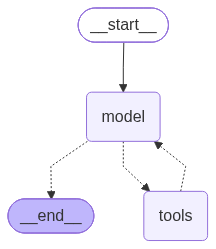

In [36]:
# Create Agent

from langchain.agents import create_agent
from langchain_openai import ChatOpenAI

llm=ChatOpenAI(temperature=0, model="gpt-4.1-mini")


system_prompt="""
        - You are a SQL agent that can interact with a MySQL database.
        - Check the database schema and table information before answering any questions.
        - Use the tools provided to you to execute SQL queries and retrieve data from the database.
        - Make the output in a tabular format for better readability.
        """

sql_agent = create_agent(
    tools=tools,
    model=llm,
    system_prompt=system_prompt
    )
sql_agent


In [44]:
# Test the agent with a question
question = "Tell me the managers name for each employee along with their employee ID and manager ID. if no manager exists, return 'CEO' as the manager name and 0 as the manager ID."

answer=sql_agent.invoke({'messages': [{'role': 'user', 'content': question}]})

In [45]:
# See the complete conversation history (all messages, in pretty format)
for message in answer["messages"]:
    message.pretty_print()

================================ Human Message =================================

Tell me the managers name for each employee along with their employee ID and manager ID. if no manager exists, return 'CEO' as the manager name and 0 as the manager ID.
================================== Ai Message ==================================
Tool Calls:
  sql_db_list_tables (call_nwkwJzVhu9g3c6g5QGSLUWS1)
 Call ID: call_nwkwJzVhu9g3c6g5QGSLUWS1
  Args:
================================= Tool Message =================================
Name: sql_db_list_tables

employees
================================== Ai Message ==================================
Tool Calls:
  sql_db_schema (call_HvNzxKPKHSSmqjICwsQMP0jJ)
 Call ID: call_HvNzxKPKHSSmqjICwsQMP0jJ
  Args:
    table_names: employees
================================= Tool Message =================================
Name: sql_db_schema


CREATE TABLE employees (
	`EMPLOYEE_ID` INTEGER NOT NULL, 
	`NAME` VARCHAR(255) NOT NULL, 
	`MANAGER_ID` INTEGER, 
	`MA

In [46]:
print(answer['messages'][-1].content)

Here is the list of employees along with their employee ID, manager name, and manager ID. If no manager exists, the manager name is shown as 'CEO' and the manager ID as 0:

| EMPLOYEE_ID | NAME           | MANAGER_NAME | MANAGER_ID |
|-------------|----------------|--------------|------------|
| 1           | John Doe       | CEO          | 0          |
| 2           | Jane Smith     | John Doe     | 1          |
| 3           | Alice Johnson  | John Doe     | 1          |
| 4           | Bob Brown      | Jane Smith   | 2          |
| 5           | Charlie Davis  | Jane Smith   | 2          |
| 6           | David Wilson   | Alice Johnson| 3          |
| 7           | Eve Thompson   | Alice Johnson| 3          |
| 8           | Frank Harris   | Bob Brown    | 4          |
| 9           | Grace Lee      | Bob Brown    | 4          |
| 10          | Hannah Clark   | Charlie Davis| 5          |


# **Manual Toolkit creation**


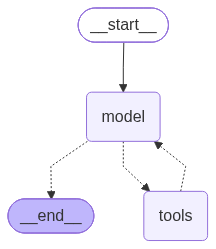

In [52]:
from langchain_core.tools import tool
from sqlalchemy import text, engine

engine = create_engine(path)



# execute_sql_query (Tool : 1)
@tool
def execute_sql_query(query: str) -> str:
    """
    Execute a SQL query on the database and return the results as a string.
    """

    try:
        with engine.connect() as alchemy_conn:
                rows = alchemy_conn.execute(text(query))
                results = rows.fetchall()
                return str(results)
    except Exception as e:
        return f"Error executing query: {e}"


# list tables (Tool : 2)
@tool
def list_tables() -> str:
    """
    List all tables in the database and return them as a string.
    """
    try:
        with engine.connect() as alchemy_conn:
            # This is a simplified example; you might need to adjust the query based on your database type
            schema_info = alchemy_conn.execute(text("show tables"))
            return str(schema_info.fetchall())
    except Exception as e:
        return f"Error retrieving schema: {e}"


# Get schema of a specific table (Tool 3 )
@tool
def get_schema(table_name: str) -> str:
    """Get the schema (columns, types) for a given table."""
    with engine.connect() as conn:
        result = conn.execute(text(f"DESCRIBE {table_name}"))
        return str(result.fetchall())

# Check SQL query syntax (Tool 4)
@tool
def check_query(query: str) -> str:
    """Check if a SQL query is syntactically correct before running it."""
    try:
        with engine.connect() as conn:
            conn.execute(text(f"EXPLAIN {query}"))   # EXPLAIN se bina data-fetch kiye syntax check hota hai
        return "Query looks valid."
    except Exception as e:
        return f"Query has an error: {e}"

tools_manual = [list_tables, get_schema, execute_sql_query, check_query]




sql_agent_manual = create_agent(
    tools=tools_manual,
    model=llm,
    system_prompt=system_prompt
    )
sql_agent_manual



In [53]:
answer=sql_agent_manual.invoke({'messages': [{'role': 'user', 'content': question}]})

In [54]:
# See the complete conversation history (all messages, in pretty format)
for message in answer["messages"]:
    message.pretty_print()

================================ Human Message =================================

Tell me the managers name for each employee along with their employee ID and manager ID. if no manager exists, return 'CEO' as the manager name and 0 as the manager ID.
================================== Ai Message ==================================
Tool Calls:
  list_tables (call_CYTmuiP0ayUglNS9AsMy5Oye)
 Call ID: call_CYTmuiP0ayUglNS9AsMy5Oye
  Args:
================================= Tool Message =================================
Name: list_tables

[('employees',)]
================================== Ai Message ==================================
Tool Calls:
  get_schema (call_Zwl1rn0QnzoemW8ZxqednuJ5)
 Call ID: call_Zwl1rn0QnzoemW8ZxqednuJ5
  Args:
    table_name: employees
================================= Tool Message =================================
Name: get_schema

[('EMPLOYEE_ID', 'int', 'NO', 'PRI', None, ''), ('NAME', 'varchar(255)', 'NO', '', None, ''), ('MANAGER_ID', 'int', 'YES', '', None, '